In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
import pandas as pd

file_path = '/content/gdrive/My Drive/DATA SET.csv'
df = pd.read_csv(file_path)

df.head()

,id,brand,categories,manufacturer,name,reviews_date,reviews_didPurchase,reviews_doRecommend,reviews_rating,reviews_text,reviews_title,reviews_userCity,reviews_userProvince,reviews_username,user_sentiment
0,AV13O1A8GV-KLJ3akUyj,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Mo...",Universal Music Group / Cash Money,Pink Friday: Roman Reloaded Re-Up (w/dvd),2012-11-30T06:21:45.000Z,NaN,NaN,5,i love this album. it's very good. more to the...,Just Awesome,Los Angeles,NaN,joshua,Positive
1,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor. This review was collected as part...,Good,NaN,NaN,dorothy w,Positive
2,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor.,Good,NaN,NaN,dorothy w,Positive
3,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",K-Y,K-Y Love Sensuality Pleasure Gel,2016-01-06T00:00:00.000Z,False,False,1,I read through the reviews on here before look...,Disappointed,NaN,NaN,rebecca,Negative
4,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",K-Y,K-Y Love Sensuality Pleasure Gel,2016-12-21T00:00:00.000Z,False,False,1,My husband bought this gel for us. The gel cau...,Irritation,NaN,NaN,walker557,Negative


In [3]:
df.shape


(30000, 15)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    30000 non-null  object
 1   brand                 30000 non-null  object
 2   categories            30000 non-null  object
 3   manufacturer          29859 non-null  object
 4   name                  30000 non-null  object
 5   reviews_date          29954 non-null  object
 6   reviews_didPurchase   15932 non-null  object
 7   reviews_doRecommend   27430 non-null  object
 8   reviews_rating        30000 non-null  int64 
 9   reviews_text          30000 non-null  object
 10  reviews_title         29810 non-null  object
 11  reviews_userCity      1929 non-null   object
 12  reviews_userProvince  170 non-null    object
 13  reviews_username      29937 non-null  object
 14  user_sentiment        29999 non-null  object
dtypes: int64(1), object(14)
memory usage

In [5]:
df.isnull().sum()

,0
id,0
brand,0
categories,0
manufacturer,141
name,0
reviews_date,46
reviews_didPurchase,14068
reviews_doRecommend,2570
reviews_rating,0
reviews_text,0


In [6]:
df['user_sentiment'].value_counts()

,count
user_sentiment,
Positive,26632
Negative,3367


In [7]:
# removing duplicates
df = df.drop_duplicates()

In [8]:
#dropping missing sentiment which is only one
df = df.dropna(subset=['reviews_text', 'user_sentiment'])

In [9]:
#converting sentiment to numerical values
df['user_sentiment'] = df['user_sentiment'].map({
    'Positive': 1,
    'Negative': 0
})

df['user_sentiment'].value_counts()

,count
user_sentiment,
1,26632
0,3367


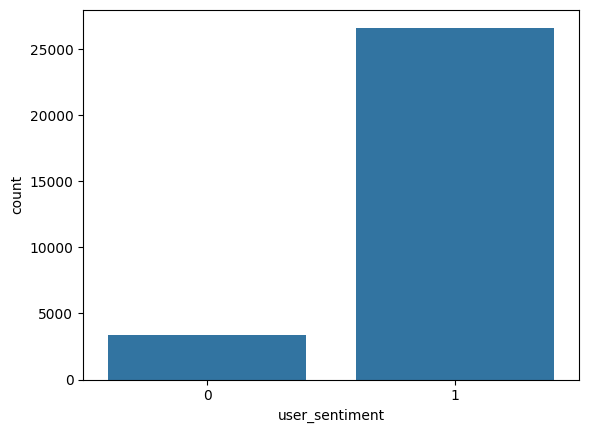

In [10]:
#distribution of sentiment
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='user_sentiment', data=df)
plt.show()

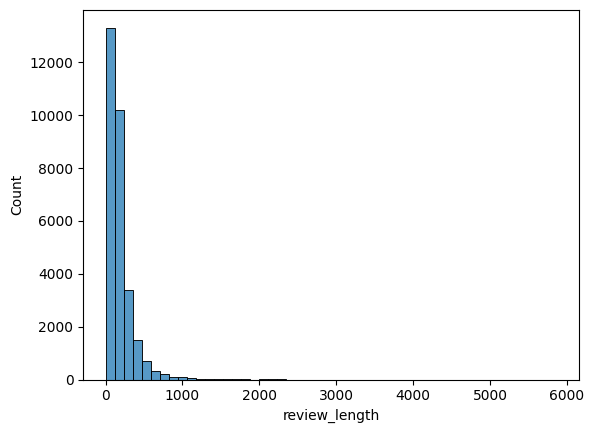

In [11]:
#review length plot
df['review_length'] = df['reviews_text'].apply(len)

sns.histplot(df['review_length'], bins=50)
plt.show()

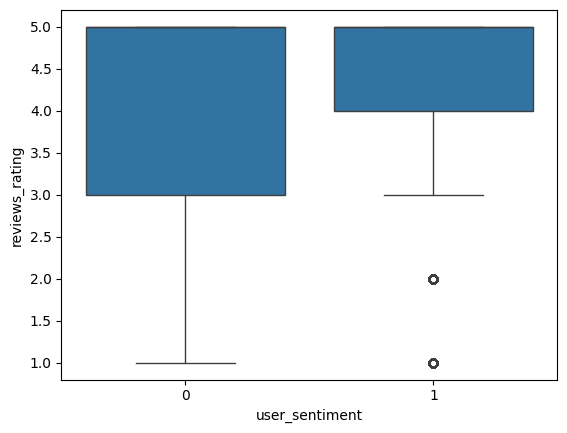

In [12]:
# rating vs sentiment
sns.boxplot(x='user_sentiment', y='reviews_rating', data=df)
plt.show()

In [13]:
# Text preprocessing
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [14]:
# Defining a function to clean the review texts like stopword removal , lemmatization , splitting the text
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

In [15]:
df['clean_text'] = df['reviews_text'].apply(preprocess)

In [16]:
df['clean_text'].head(2)

,clean_text
0,love album good hip hop side current pop sound...
1,good flavor review collected part promotion


In [17]:
# train test split
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['user_sentiment']
)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (23999, 17)
Test shape: (6000, 17)


In [18]:
# TF-IDF vectorization only on training data set
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1,2)
)

# Fit only on training text
X_train = vectorizer.fit_transform(train_df['clean_text'])
y_train = train_df['user_sentiment']

# Transform test text (NO fit here)
X_test = vectorizer.transform(test_df['clean_text'])
y_test = test_df['user_sentiment']

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (23999, 2000)
X_test shape: (6000, 2000)


In [19]:
# class imbalance handling using class weights
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))

print("Class Weights:", class_weight_dict)

Class Weights: {np.int64(0): np.float64(4.454157386785449), np.int64(1): np.float64(0.5632245951654541)}


In [20]:
# Logistic regression model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_model = LogisticRegression(
    class_weight=class_weight_dict,
    max_iter=1000
)

log_model.fit(X_train, y_train)

LogisticRegression(class_weight={np.int64(0): np.float64(4.454157386785449),
                                 np.int64(1): np.float64(0.5632245951654541)},
                   max_iter=1000)

In [21]:
# report of logistic regression
y_pred_log = log_model.predict(X_test)

print("Logistic Regression Report:\n")
print(classification_report(y_test, y_pred_log))

Logistic Regression Report:

              precision    recall  f1-score   support

           0       0.53      0.91      0.67       673
           1       0.99      0.90      0.94      5327

    accuracy                           0.90      6000
   macro avg       0.76      0.90      0.80      6000
weighted avg       0.94      0.90      0.91      6000



In [22]:
# Random forest model
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight=class_weight_dict,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Report:

              precision    recall  f1-score   support

           0       0.86      0.66      0.75       673
           1       0.96      0.99      0.97      5327

    accuracy                           0.95      6000
   macro avg       0.91      0.82      0.86      6000
weighted avg       0.95      0.95      0.95      6000



In [23]:
# XG boost model
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=class_weight_dict[1] / class_weight_dict[0],
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Report:\n")
print(classification_report(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:18:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Report:

              precision    recall  f1-score   support

           0       0.49      0.88      0.63       673
           1       0.98      0.88      0.93      5327

    accuracy                           0.88      6000
   macro avg       0.74      0.88      0.78      6000
weighted avg       0.93      0.88      0.90      6000



In [24]:
# Hyper parameter tuning for Random Forest model
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [None, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

rf = RandomForestClassifier(
    class_weight=class_weight_dict,
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}


In [25]:
# Testing
best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.77      0.77      0.77       673
           1       0.97      0.97      0.97      5327

    accuracy                           0.95      6000
   macro avg       0.87      0.87      0.87      6000
weighted avg       0.95      0.95      0.95      6000



In [26]:
# From the above three results I can see that the better class balance is present in the random forest model.
# Logistic regression model has high recall but low precission, many postives are being classified as negetives
# XG boost is also giving similar kind of behaviour
# Since recommendation system should avoid recomending negetively perceived product, the F1 score and balanced precission has been priorotizes
# So I have choosen random forest model.
# Then I have tuned the hyperparameters and found the best fitting parameters
# I have also taken the tuned RF model and tested. The results have improved. That is why i have kept that model.

In [27]:
# saving the model
import joblib

joblib.dump(best_rf, "sentiment_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [28]:
df.head(2)

,id,brand,categories,manufacturer,name,reviews_date,reviews_didPurchase,reviews_doRecommend,reviews_rating,reviews_text,reviews_title,reviews_userCity,reviews_userProvince,reviews_username,user_sentiment,review_length,clean_text
0,AV13O1A8GV-KLJ3akUyj,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Mo...",Universal Music Group / Cash Money,Pink Friday: Roman Reloaded Re-Up (w/dvd),2012-11-30T06:21:45.000Z,NaN,NaN,5,i love this album. it's very good. more to the...,Just Awesome,Los Angeles,NaN,joshua,1,201,love album good hip hop side current pop sound...
1,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor. This review was collected as part...,Good,NaN,NaN,dorothy w,1,62,good flavor review collected part promotion


In [29]:
# Recomemdation system
# user user based recomendation

In [30]:
dummy = df[['reviews_username', 'id', 'reviews_rating']].copy()

dummy = dummy.dropna()
dummy = dummy.drop_duplicates()

In [31]:
rating_matrix = dummy.pivot_table(
    index='reviews_username',
    columns='id',
    values='reviews_rating'
)

In [32]:
rating_matrix.head()

id,AV13O1A8GV-KLJ3akUyj,AV14LG0R-jtxr-f38QfS,AV16khLE-jtxr-f38VFn,AV1YGDqsGV-KLJ3adc-O,AV1YIch7GV-KLJ3addeG,AV1YlENIglJLPUi8IHsX,AV1YmBrdGV-KLJ3adewb,AV1YmDL9vKc47QAVgr7_,AV1Ymf_rglJLPUi8II2v,AV1Yn94nvKc47QAVgtst,...,AVpfrfHF1cnluZ0-pRai,AVpfrgjFLJeJML43BvCc,AVpfs0tUilAPnD_xgqN2,AVpfsQoeilAPnD_xgfx5,AVpfshNsLJeJML43CB8q,AVpfthSailAPnD_xg3ON,AVpftikC1cnluZ0-p31V,AVpftymALJeJML43CZ6y,AVpfv4TlilAPnD_xhjNS,AVpfvieo1cnluZ0-qdnu
reviews_username,,,,,,,,,,,,,,,,,,,,,
00dog3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
00sab00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
01impala,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
02dakota,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
02deuce,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
# creating binary interaction matrix
interaction_matrix = rating_matrix.copy()

# Rated items → 0
interaction_matrix[~interaction_matrix.isna()] = 0

# Non-rated items → 1
interaction_matrix[interaction_matrix.isna()] = 1

In [34]:
interaction_matrix.head()

id,AV13O1A8GV-KLJ3akUyj,AV14LG0R-jtxr-f38QfS,AV16khLE-jtxr-f38VFn,AV1YGDqsGV-KLJ3adc-O,AV1YIch7GV-KLJ3addeG,AV1YlENIglJLPUi8IHsX,AV1YmBrdGV-KLJ3adewb,AV1YmDL9vKc47QAVgr7_,AV1Ymf_rglJLPUi8II2v,AV1Yn94nvKc47QAVgtst,...,AVpfrfHF1cnluZ0-pRai,AVpfrgjFLJeJML43BvCc,AVpfs0tUilAPnD_xgqN2,AVpfsQoeilAPnD_xgfx5,AVpfshNsLJeJML43CB8q,AVpfthSailAPnD_xg3ON,AVpftikC1cnluZ0-p31V,AVpftymALJeJML43CZ6y,AVpfv4TlilAPnD_xhjNS,AVpfvieo1cnluZ0-qdnu
reviews_username,,,,,,,,,,,,,,,,,,,,,
00dog3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
00sab00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
01impala,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
02dakota,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
02deuce,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [35]:
# mean and pairwise distance
user_mean = rating_matrix.mean(axis=1)
rating_matrix_centered = rating_matrix.sub(user_mean, axis=0)
rating_matrix_centered = rating_matrix_centered.fillna(0)

In [36]:
# adjusted cosine similarity between user and user
from sklearn.metrics.pairwise import cosine_similarity

user_similarity = cosine_similarity(rating_matrix_centered)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=rating_matrix.index,
    columns=rating_matrix.index
)

In [37]:
# predicting ratings. Using dot product to get the prediction for unrated items
import numpy as np
predicted = np.dot(user_similarity, rating_matrix_centered)

In [38]:
similarity_sum = np.abs(user_similarity).sum(axis=1).reshape(-1,1)

predicted = predicted / similarity_sum

/tmp/ipython-input-622/3813247629.py:3: RuntimeWarning: invalid value encountered in divide
  predicted = predicted / similarity_sum


In [39]:
predicted = predicted + user_mean.values.reshape(-1,1)

predicted_df = pd.DataFrame(
    predicted,
    index=rating_matrix.index,
    columns=rating_matrix.columns
)

In [40]:
final_prediction = predicted_df * interaction_matrix

In [41]:
def recommend_items(username, top_n=20):

    user_predictions = final_prediction.loc[username]

    recommended_items = user_predictions.sort_values(ascending=False).head(top_n)

    return recommended_items

In [42]:
df.head(3)

,id,brand,categories,manufacturer,name,reviews_date,reviews_didPurchase,reviews_doRecommend,reviews_rating,reviews_text,reviews_title,reviews_userCity,reviews_userProvince,reviews_username,user_sentiment,review_length,clean_text
0,AV13O1A8GV-KLJ3akUyj,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Mo...",Universal Music Group / Cash Money,Pink Friday: Roman Reloaded Re-Up (w/dvd),2012-11-30T06:21:45.000Z,NaN,NaN,5,i love this album. it's very good. more to the...,Just Awesome,Los Angeles,NaN,joshua,1,201,love album good hip hop side current pop sound...
1,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor. This review was collected as part...,Good,NaN,NaN,dorothy w,1,62,good flavor review collected part promotion
2,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor.,Good,NaN,NaN,dorothy w,1,12,good flavor


In [43]:
# check function is working or not
rating_matrix.index[:10]
active_users = rating_matrix.count(axis=1)
active_users = active_users[active_users > 5]

test_user = active_users.index[0]
print("Testing user:", test_user)
print("Testing for user:", test_user)
rated_items = rating_matrix.loc[test_user].dropna()
print("Items already rated by user:")
print(rated_items.head())
recommendations = recommend_items(test_user, top_n=20)

print("Recommended Items:")
print(recommendations)

Testing user: alex
Testing for user: alex
Items already rated by user:
id
AVpe41TqilAPnD_xQH3d    3.0
AVpe5c23LJeJML43xybi    5.0
AVpe7GIELJeJML43yZfu    5.0
AVpf0eb2LJeJML43EVSt    5.0
AVpf0thK1cnluZ0-r8vR    5.0
Name: alex, dtype: float64
Recommended Items:
id
AVpe59io1cnluZ0-ZgDU    4.582506
AVpfRTh1ilAPnD_xYic2    4.561234
AV16khLE-jtxr-f38VFn    4.520184
AVpfJcHuLJeJML433ZrY    4.517506
AVpf3VOfilAPnD_xjpun    4.516079
AVpfnRuSilAPnD_xfB8l    4.515677
AVpfDI3xilAPnD_xTz-k    4.511591
AVpfPnrU1cnluZ0-g9rL    4.511587
AVpfrTyiLJeJML43BrSI    4.510570
AVpfm8yiLJeJML43AYyu    4.510025
AVpfOIrkilAPnD_xXgDG    4.509574
AVpfNc9cLJeJML434tza    4.509529
AVpfpM2yilAPnD_xfmDG    4.508271
AVpf5olc1cnluZ0-tPrO    4.507820
AVpfluP1ilAPnD_xejxO    4.507623
AVpfM_ytilAPnD_xXIJb    4.507534
AVpfGuDrLJeJML432fDz    4.507441
AVpftikC1cnluZ0-p31V    4.507405
AVpf63aJLJeJML43F__Q    4.507105
AVpe_dxlilAPnD_xSiHI    4.506840
Name: alex, dtype: float64


In [44]:
# Item item based colaborative filtering
item_matrix = rating_matrix.T

In [45]:
# mean and pairwise distance
item_mean = item_matrix.mean(axis=1)

item_centered = item_matrix.sub(item_mean, axis=0)
item_centered = item_centered.fillna(0)

In [46]:
# adjusted cosine similarity
item_similarity = cosine_similarity(item_centered)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_centered.index,
    columns=item_centered.index
)

In [47]:
# Convert rating_matrix NaNs to 0 for multiplication
rating_filled = rating_matrix.fillna(0)

# Multiply rating matrix with item similarity
predicted_ratings = np.dot(rating_filled.values, item_similarity_df.values)

# Normalize by sum of absolute similarity
sim_sums = np.abs(item_similarity_df.values).sum(axis=1)

predicted_ratings = predicted_ratings / sim_sums

predicted_df_item = pd.DataFrame(
    predicted_ratings,
    index=rating_matrix.index,
    columns=rating_matrix.columns
)

/tmp/ipython-input-622/1786743272.py:10: RuntimeWarning: invalid value encountered in divide
  predicted_ratings = predicted_ratings / sim_sums


In [48]:
# masking already rated items
dummy_mask = rating_matrix.copy()
dummy_mask[~dummy_mask.isna()] = 0
dummy_mask[dummy_mask.isna()] = 1

final_prediction_item = predicted_df_item * dummy_mask

In [49]:
# recomendation function
def recommend_items_item_based(user, top_n=20):
    if user not in final_prediction_item.index:
        return "User not found"

    recommendations = final_prediction_item.loc[user].sort_values(ascending=False)

    return recommendations.head(top_n)

In [50]:
# testing
active_users = rating_matrix.count(axis=1)
active_users = active_users[active_users > 5]

test_user = active_users.index[0]

print("Testing user:", test_user)
print(recommend_items_item_based(test_user, top_n=20))

Testing user: alex
id
AVpfDI3xilAPnD_xTz-k    0.320320
AVpfE7puilAPnD_xUcCW    0.256181
AVpfJcHuLJeJML433ZrY    0.146140
AVpfOIrkilAPnD_xXgDG    0.133557
AVpe9W4D1cnluZ0-avf0    0.100899
AVpf5olc1cnluZ0-tPrO    0.094854
AVpe59io1cnluZ0-ZgDU    0.094305
AVpfNc9cLJeJML434tza    0.076327
AVpf0pfrilAPnD_xi6s_    0.066607
AVpfTVkcilAPnD_xZLts    0.060438
AVpf4WWN1cnluZ0-s7Wj    0.056673
AVpfQtEm1cnluZ0-hUpe    0.051891
AVpe8xjUilAPnD_xRkxC    0.041824
AVpe4pnBilAPnD_xQDeb    0.039975
AVpf7I3i1cnluZ0-tnL6    0.038943
AVpfthSailAPnD_xg3ON    0.038758
AVpfBU2S1cnluZ0-cJsO    0.037578
AVpfPx6V1cnluZ0-hA5y    0.036873
AVpe6PCDLJeJML43yFQH    0.031732
AVpe6n2_LJeJML43yOgE    0.031072
Name: alex, dtype: float64


In [51]:
# Finding better recomendation system
# Method used = RMSE

# Creating a mask of actual rating
actual_mask = ~rating_matrix.isna()

# Fill NaN with 0 only for computation
actual_ratings = rating_matrix.fillna(0)

In [52]:
# RMSE function
from sklearn.metrics import mean_squared_error

def calculate_rmse(predicted_df, actual_df):

    # Flatten arrays
    predicted = predicted_df.values.flatten()
    actual = actual_df.values.flatten()

    # Keep only valid entries (where actual rating exists)
    mask = actual > 0

    predicted = predicted[mask]
    actual = actual[mask]

    return np.sqrt(mean_squared_error(actual, predicted))

In [53]:
# RMSE for user-user and item-item
predicted_df = predicted_df.fillna(0)
predicted_df_item = predicted_df_item.fillna(0)

rmse_user = calculate_rmse(predicted_df, actual_ratings)
rmse_item = calculate_rmse(predicted_df_item, actual_ratings)

print("User-User RMSE:", rmse_user)
print("Item-Item RMSE:", rmse_item)

User-User RMSE: 4.477759990671128
Item-Item RMSE: 1.17635179893805


In [54]:
# From the above two RMSE scores it is clear that item-item based recomendation is more effective thant the user-user based
# THe reason is many users have very few ratings and sparsity is high
# Item based recomendation works better because items are rated by many users and the similarity is more satble.

In [55]:
# As the next step implementing the Random forest model saved as the sentiment analysis for recomendation system
# Get top 20 recomendation
def get_top_20_cf(user):
    return final_prediction_item.loc[user]\
        .sort_values(ascending=False)\
        .head(20)\
        .index.tolist()

In [56]:
# Computing percentafe of postive for each product (TRAIN only)
def sentiment_percentage_train(product_list):

    product_sentiment = {}

    for product in product_list:

        # Only use training dataset
        product_reviews = train_df[train_df['id'] == product]

        if len(product_reviews) == 0:
            product_sentiment[product] = 0
            continue

        # Transform text
        X = vectorizer.transform(product_reviews['clean_text'])

        # Predict sentiment
        preds = best_rf.predict(X)

        # Calculate % positive
        positive_percentage = (preds.sum() / len(preds)) * 100

        product_sentiment[product] = positive_percentage

    return product_sentiment

In [57]:
# Final top 5 selection
def hybrid_sentiment_filter(user):

    # Step 1: Get top 20 CF recommendations
    top_20 = get_top_20_cf(user)

    # Step 2: Get sentiment percentages
    sentiment_dict = sentiment_percentage_train(top_20)

    # Convert to DataFrame
    sentiment_df = pd.DataFrame(
        sentiment_dict.items(),
        columns=['Product', 'PositivePercentage']
    )

    # Sort by highest % positive
    sentiment_df = sentiment_df.sort_values(
        by='PositivePercentage',
        ascending=False
    )

    # Return top 5
    return sentiment_df.head(5)

In [58]:
# Testing
active_users = rating_matrix.count(axis=1)
active_users = active_users[active_users > 5]

test_user = active_users.index[0]

print("Testing user:", test_user)

hybrid_sentiment_filter(test_user)

Testing user: alex


,Product,PositivePercentage
1,AVpfE7puilAPnD_xUcCW,100.0
17,AVpfPx6V1cnluZ0-hA5y,100.0
8,AVpf0pfrilAPnD_xi6s_,100.0
10,AVpf4WWN1cnluZ0-s7Wj,100.0
13,AVpe4pnBilAPnD_xQDeb,100.0


In [58]:
# As the data set is mostly tends towards positive reviews, as a fact most reviews will be positive.
# This may bias the recomendation such as where there is only one review that will also come under 100% postive review percentage.
# So I have added a constarint which shows that all the products having more than five reviews will be considered for the recomendation.

In [60]:
from google.colab import files

files.download("sentiment_model.pkl")
files.download("tfidf_vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>